# Simulating an acquisition

Every `test_tiffs/` fixture used across `../analyses/` was generated the same way this
notebook demonstrates: `pyS3M.simulation.pattern_source.simulate_acquisition` renders a
synthetic Bayer-mosaic camera stack from a pattern image, with a known injected ground
truth — the same backend `claude/generate_test_fixtures.py` uses internally, exposed here
as a plain, reusable function.

The workflow: load a pattern image → assign a dye to each detected colour → simulate →
write to disk as a real, fittable TIFF stack → round-trip it through the exact same
`AnalysisPipeline.fit` pipeline `01_getting_started_smlm_fitting.ipynb` used, to see
recovered positions against the injected ground truth.

INFO:pyS3M.AnalysisPipeline:AnalysisPipeline initialised (camera=ximea, pixel_size=0.0690 µm)


INFO:pyS3M.AnalysisPipeline:Calibration loaded from /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/Camera_Calibrations/Ximea_Camera


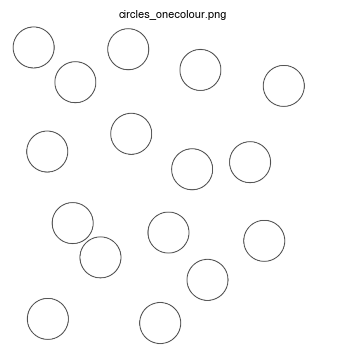

In [1]:
from pathlib import Path
import tempfile
import json
import numpy as np
import matplotlib.pyplot as plt

from pyS3M.AnalysisPipeline import AnalysisPipeline, FittingConfig
from pyS3M.Constants import AnalysisConfig
from pyS3M.clustering import ClusteringConfig
from pyS3M.simulation import pattern_source
import pyS3M.IOFunctions as IOFunctions
import pyS3M.PlottingBase as PlottingBase

REPO_ROOT = Path.cwd().resolve().parents[1]
PATTERN_PATH = REPO_ROOT / "test_tiffs" / "example_SR_patterns" / "circles_onecolour.png"
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"

cfg = AnalysisConfig(display=False)
pipe = AnalysisPipeline(camera="ximea", config=cfg)
pipe.load_calibration(CALIBRATION_DIR)
plotter = PlottingBase.PublicationPlotter()

fig, ax = plotter.create_figure()
# origin="upper" (not image_plot's microscopy-image default "lower") -- this is a plain
# top-to-bottom PNG, not a physically y-up camera frame; "lower" would flip it.
plotter.image_plot(ax, plt.imread(PATTERN_PATH), origin="upper", title=PATTERN_PATH.name)
plt.show()

## Assign a dye to each detected pattern colour

`pattern_source.mask_from_image` Otsu-thresholds the pattern into one boolean mask per
foreground colour — `circles_onecolour.png` has just one, pure black `(0, 0, 0)`. Candidate
molecule positions are then sampled from within that mask at the requested density.

In [2]:
from pyS3M.simulation.pattern_source import mask_from_image

masks = mask_from_image(PATTERN_PATH)
{colour: int(mask.sum()) for colour, mask in masks.items()}

{(0, 0, 0): 5033}

### Where does the filter go?

`simulate_acquisition`'s `filter_names` argument is the emission-filter knob — the
parameter users will most want to change for a realistic simulation, so it's worth being
explicit about it here. Pass the same optical filter(s) a real acquisition's emission path
would use (e.g. a bandpass filter in front of the camera), and it is applied to *every*
dye in `colour_to_dye` — a plain dye name, a `Scatterer`, or a `NileRedEnvironment` alike
— before the per-channel colour ratios (and so the rendered Bayer frames) are computed.
Filter names are looked up in the same spectral database as dye names; list the available
ones with `SpectralFunctions.Spectral_Funcs().filter_names`.

Omitting `filter_names` (the default, `None`) simulates an *unfiltered* emission spectrum
— a fine quick sanity check, but not representative of a real acquisition, where an
emission filter is almost always present and materially shifts the colour split (and so the
recovered average emission wavelength) a dye is detected with. Below we use
`chroma-et670-50m`, a 670/50 nm bandpass real single-molecule setups commonly put in the
red channel for a far-red dye like ATTO 647N — a "reasonable" choice for this simulation.

### Using your own emission spectrum

`colour_to_dye` doesn't have to be a database dye name — `Scatterer` and
`NileRedEnvironment` (see their docstrings) both ultimately hand a plain array to
`Spectral_Funcs.get_pixel_fractions_rawspectra`, the same function `simulate_acquisition`
uses internally to turn *any* non-database spectrum into per-channel photon fractions.
It's worth seeing directly what that function needs from an array you build yourself, since
it's easy to get the scale wrong.

Say you want a hypothetical dye with a simple Gaussian emission, centred at 550 nm with a
20 nm FWHM — e.g. pasted in from a spectrometer trace in arbitrary intensity ("counts")
units, peak height 500. The *shape* is all that matters physically, but for the resulting
photon fractions to be correct, the array has to integrate to 1 over wavelength — i.e.
`np.trapz(spectrum, wavelength) == 1` — because `get_pixel_fractions_rawspectra` treats it
as a probability density over emission wavelength, not a raw intensity trace. Skip that and
any expected-photon-count calculation you do by hand from the un-normalised array is wrong
by whatever factor its integral is off by; `get_pixel_fractions_rawspectra` itself always
renormalises before using a spectrum, so it *always* returns a correct answer regardless of
input scale — and now warns you when it had to, so a scaling mistake like this doesn't
silently go unnoticed.

In [3]:
import pyS3M.SpectralFunctions as SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()
R_qe, G_qe, B_qe, wl = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_qe, G_qe, R_qe])  # (B, G, R) order

sigma_nm = S_F.fwhm_sigma_conversion(20.0, sigma_given=False)
raw_spectrum = 500.0 * np.exp(-0.5 * ((wl - 550.0) / sigma_nm) ** 2)  # NOT normalised
print(f"raw_spectrum integral = {np.trapz(raw_spectrum, wl):.1f} (should be 1)")

# get_pixel_fractions_rawspectra warns (see below) and corrects this for you --
# the returned fracs are the true per-channel photon fractions either way.
avg_wl, fracs = S_F.get_pixel_fractions_rawspectra(raw_spectrum, wl, pixel_QYs)
n_photons_total = 4000

# What happens if you instead compute expected photons per channel by hand from
# the un-normalised array, forgetting to divide by its own integral first:
naive_photons = n_photons_total * np.trapz(raw_spectrum[None, :] * pixel_QYs, wl, axis=1)
correct_photons = n_photons_total * fracs
print(f"naive (WRONG) per-channel photons:   {naive_photons.round(0)}, "
      f"sum={naive_photons.sum():.0f} (of {n_photons_total} total -- impossible)")
print(f"correct per-channel photons:         {correct_photons.round(0)}, "
      f"sum={correct_photons.sum():.0f} (of {n_photons_total} total)")

raw_spectrum integral = 10644.7 (should be 1)
naive (WRONG) per-channel photons:   [  2530564.  26799779.   1500197.], sum=30830540 (of 4000 total -- impossible)
correct per-channel photons:         [  238.  2518.   141.], sum=2896 (of 4000 total)


/tmp/ipykernel_2211606/3187285727.py:13: UserWarning: get_pixel_fractions_rawspectra: input spectrum/spectra do not integrate to 1 over `wavelength` (got [ 10644.67019431]); normalising automatically, but double-check the scaling of the spectrum you supplied -- a spectrum representing an emission probability density should integrate to 1.
  avg_wl, fracs = S_F.get_pixel_fractions_rawspectra(raw_spectrum, wl, pixel_QYs)


## Simulate

Calibration maps must be pre-cropped to the field of view the pattern image implies —
`image_fov_camera_pixels` computes that size (the same computation `simulate_acquisition`
does internally, exposed so callers can crop consistently first).

In [4]:
camera_pixel_size_nm = pipe.pixel_size * 1000.0
width, height = pattern_source.image_fov_camera_pixels(PATTERN_PATH, camera_pixel_size_nm)
print(f"Field of view: {width}x{height} camera px")

bayer_stack, ground_truth, width, height, avg_wl_nm = pattern_source.simulate_acquisition(
    image=PATTERN_PATH,
    colour_to_dye={(0, 0, 0): "ATTO 647N"},
    camera=pipe.camera,
    pixel_size_um=pipe.pixel_size,
    gain_map=pipe.gain_map[:height, :width],
    offset_map=pipe.offset_map[:height, :width],
    variance_map=pipe.variance[:height, :width],
    rqe_map=pipe.rqe[:height, :width],
    n_frames=200,
    density_per_um2=0.1,
    modality="PAINT",
    filter_names=["chroma-et670-50m"],  # emission filter -- see markdown above
    photon_range=(1000.0, 10000.0),  # per-frame photon budget: on every frame, one value is
                                      # drawn uniformly from this range and shared by every
                                      # candidate that's ON that frame (simulate_acquisition's
                                      # own default).
    background_photons=10.0, 
    rng=np.random.default_rng(0),
)
print(f"{bayer_stack.shape[0]} frames simulated, {len(ground_truth)} candidates, "
      f"recommended Peak λ = {avg_wl_nm / 1000.0:.3f} µm")
ground_truth.head()

Field of view: 145x145 camera px


200 frames simulated, 38 candidates, recommended Peak λ = 0.668 µm


,dye,colour,xc_nm,yc_nm,n_frames_on
0,ATTO 647N,#000000,6658.646235,8018.131244,10
1,ATTO 647N,#000000,4250.474283,6175.207508,2
2,ATTO 647N,#000000,1096.624795,4513.972365,0
3,ATTO 647N,#000000,2517.259327,2099.554882,1
4,ATTO 647N,#000000,8310.172565,2484.092617,8


## A raw simulated frame

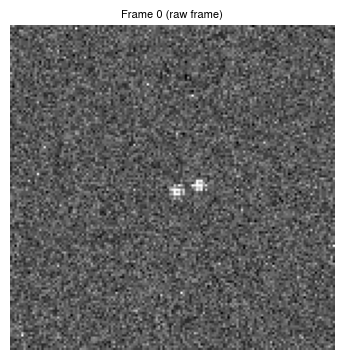

In [5]:
fig, ax = plotter.one_column_plot()
ax = plotter.image_plot(ax, bayer_stack[0], vmin=np.percentile(bayer_stack[0], 0.1),
                       vmax=np.percentile(bayer_stack[0], 99.9))
ax[0].set_title("Frame 0 (raw frame)")
plt.show()

## Write to disk and fit — the same pipeline every analysis notebook uses

Written to a temporary directory here so running this notebook doesn't leave files behind
in the repo; `claude/generate_test_fixtures.py` does the same write (TIFF + `metadata.txt`
ROI sidecar) but into `test_tiffs/` to build a permanent fixture instead.

In [6]:
out_dir = Path(tempfile.mkdtemp()) / "simulated_acquisition"
out_dir.mkdir(parents=True)
io = IOFunctions.IO_Functions()
io.write_tiff(bayer_stack, out_dir / "sim_MMStack_Default.ome.tif", bit="uint16", pixel_size=pipe.pixel_size)
with open(out_dir / "sim_MMStack_Default_metadata.txt", "w") as f:
    json.dump({"FrameKey-0-0-0": {"ROI": f"0-0-{width}-{height}"}}, f)

fc = FittingConfig(peak_wavelength=avg_wl_nm / 1000.0, pfa=1e-3)
pipe.fit(out_dir, mode="smlm", fitting_config=fc)
locs = pipe.load_localisations(out_dir)
cc = ClusteringConfig(min_cluster_size=2)  # STORM: see 01_getting_started_smlm_fitting.ipynb
sm_db, sf_db = pipe.filter_and_cluster(locs, clustering_config=cc)
print(f"{len(sm_db)} molecules recovered from {len(locs)} raw localisations "
      f"({len(ground_truth)} candidates injected)")

INFO:pyS3M.AnalysisPipeline:Starting smlm fit on /tmp/tmpxs06jpbk/simulated_acquisition


INFO:pyS3M.SR_Functions:Processing file 1/1: 200 frames in chunks of 1000


INFO:pyS3M.SR_Functions:  Processing chunk: frames 0-199


Detecting puncta:   0%|          | 0/200 [00:00<?, ?it/s]

INFO:pyS3M.SR_Functions:  Found 307 puncta across all chunks


INFO:pyS3M.AnalysisPipeline:smlm fit complete


INFO:pyS3M.AnalysisPipeline:Loaded 193 localisations from 1 file(s) in /tmp/tmpxs06jpbk/simulated_acquisition


INFO:pyS3M.AnalysisPipeline:Clustering with HDBSCAN (min_cluster_size=2)


INFO:pyS3M.clustering.hdbscan_clusterer:Using fast_hdbscan for HDBSCAN clustering


13 molecules recovered from 193 raw localisations (38 candidates injected)


## Recovered positions vs. injected ground truth

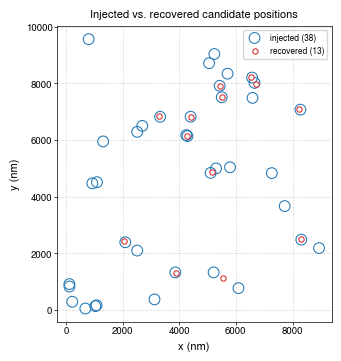

In [7]:
pixel_size_nm = pipe.pixel_size * 1000.0
fig, ax = plotter.create_figure()
plotter.scatter_plot(ax, ground_truth["xc_nm"], ground_truth["yc_nm"], xlabel="x (nm)", ylabel="y (nm)",
                      size=60, edgecolor="tab:blue", facecolor="none", label=f"injected ({len(ground_truth)})")
plotter.scatter_plot(ax, sm_db["xc"] * pixel_size_nm, sm_db["yc"] * pixel_size_nm, xlabel="x (nm)", ylabel="y (nm)",
                      size=15, color="tab:red", edgecolor="tab:red", label=f"recovered ({len(sm_db)})")
ax.set_aspect("equal")
ax.set_title("Injected vs. recovered candidate positions")
ax.legend()
plt.show()

## Next: `02_exemplar_psf_and_bayer_grid.ipynb`